# Phần 3: Tiền xử lý dữ liệu văn bản
- Bộ dữ liệu sử dụng: **IMDB Dataset of 50K Movie Reviews** (https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)
- Bộ dữ liệu có 50000 mẫu, gồm 2 thuộc tính:
  - `review`: Nội dung đánh giá
  - `sentiment` (target): Nhãn lớp (positive hay negative)

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import re
from collections import Counter
from PIL import Image, ImageDraw, ImageFont
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import numpy as np
from scipy.stats import linregress
from scipy.stats import ks_2samp
import nltk
import spacy
from sklearn.model_selection import train_test_split
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
import math
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC
from sentence_transformers import SentenceTransformer

c:\Users\lemin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
try:
  ROOT = Path(__file__).resolve().parent.parent
except NameError:
  ROOT = Path.cwd()
  for candidate in [ROOT, ROOT.parent, ROOT.parent.parent]:
    if (candidate / 'data').is_dir():
      ROOT = candidate
      break
  else:
    raise RuntimeError('Could not find project root directory')

DATA_DIR = ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
print(f'ROOT: {ROOT}')
print(f'DATA_DIR: {DATA_DIR}')
print(f'RAW_DIR: {RAW_DIR}')
assert (RAW_DIR / 'IMDB Dataset.csv').is_file(), 'IMDB Dataset.csv not found in data directory'

ROOT: d:\Downloads\HCMUS-HocTap\DM\Đồ án 1\lab1-data-mining
DATA_DIR: d:\Downloads\HCMUS-HocTap\DM\Đồ án 1\lab1-data-mining\data
RAW_DIR: d:\Downloads\HCMUS-HocTap\DM\Đồ án 1\lab1-data-mining\data\raw


In [3]:
df = pd.read_csv(RAW_DIR / 'IMDB Dataset.csv')
print(f'Loaded dataset with {len(df)} rows and {len(df.columns)} columns')
print(df.head())

Loaded dataset with 50000 rows and 2 columns
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


## 1. Phân tích thống kê văn bản

### a. Tính và vẽ phân phối độ dài văn bản (số từ, số ký tự) theo nhãn lớp. Kiểm định Mann-Whitney U test để xác định liệu các lớp có sự khác biệt đáng kể về độ dài không.

Thống kê mô tả theo nhãn lớp:


word_len                                  char_len                  \
             count    mean median     std min   max    count     mean median   
sentiment                                                                      
negative     25000  229.46  174.0  164.95   4  1522    25000  1294.06  973.0   
positive     25000  232.85  172.0  177.50  10  2470    25000  1324.80  968.0   

                               
               std min    max  
sentiment                      
negative    945.89  32   8969  
positive   1031.49  65  13704

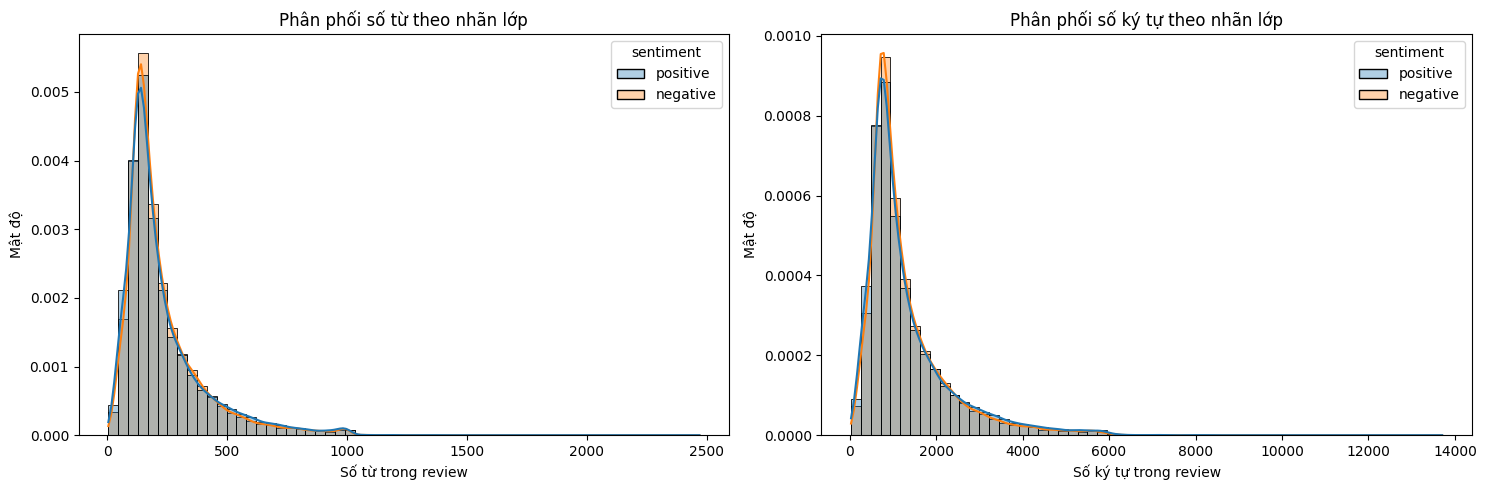

Mann-Whitney U test (two-sided):
- Word length: U = 316,029,735, p-value = 0.02872
- Character length: U = 314,697,643, p-value = 0.1733

Kết luận ở mức ý nghĩa 0.05:
- Số từ: Có khác biệt có ý nghĩa thống kê giữa hai lớp.
- Số ký tự: Không có khác biệt có ý nghĩa thống kê giữa hai lớp.


In [4]:
# Tạo bảng đặc trưng độ dài văn bản
text_stats = df[['review', 'sentiment']].copy()
text_stats['review'] = text_stats['review'].astype(str)
text_stats['word_len'] = text_stats['review'].str.split().str.len()
text_stats['char_len'] = text_stats['review'].str.len()

print('Thống kê mô tả theo nhãn lớp:')
display(
    text_stats.groupby('sentiment')[['word_len', 'char_len']]
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .round(2)
)

# Vẽ phân phối độ dài theo nhãn lớp
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    data=text_stats,
    x='word_len',
    hue='sentiment',
    bins=60,
    stat='density',
    common_norm=False,
    kde=True,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title('Phân phối số từ theo nhãn lớp')
axes[0].set_xlabel('Số từ trong review')
axes[0].set_ylabel('Mật độ')

sns.histplot(
    data=text_stats,
    x='char_len',
    hue='sentiment',
    bins=60,
    stat='density',
    common_norm=False,
    kde=True,
    alpha=0.35,
    ax=axes[1],
)
axes[1].set_title('Phân phối số ký tự theo nhãn lớp')
axes[1].set_xlabel('Số ký tự trong review')
axes[1].set_ylabel('Mật độ')

plt.tight_layout()
plt.show()

# Mann-Whitney U test (2 phía)
alpha = 0.05
neg_word = text_stats.loc[text_stats['sentiment'] == 'negative', 'word_len']
pos_word = text_stats.loc[text_stats['sentiment'] == 'positive', 'word_len']
neg_char = text_stats.loc[text_stats['sentiment'] == 'negative', 'char_len']
pos_char = text_stats.loc[text_stats['sentiment'] == 'positive', 'char_len']

u_word, p_word = mannwhitneyu(neg_word, pos_word, alternative='two-sided')
u_char, p_char = mannwhitneyu(neg_char, pos_char, alternative='two-sided')

print('Mann-Whitney U test (two-sided):')
print(f'- Word length: U = {u_word:,.0f}, p-value = {p_word:.4g}')
print(f'- Character length: U = {u_char:,.0f}, p-value = {p_char:.4g}')

print('\nKết luận ở mức ý nghĩa 0.05:')
print(f"- Số từ: {'Có' if p_word < alpha else 'Không có'} khác biệt có ý nghĩa thống kê giữa hai lớp.")
print(f"- Số ký tự: {'Có' if p_char < alpha else 'Không có'} khác biệt có ý nghĩa thống kê giữa hai lớp.")

### b. Vẽ word cloud và bảng top-50 từ phổ biến nhất theo từng lớp. Tính type-token ratio (TTR) để đánh giá độ phong phú từ vựng.

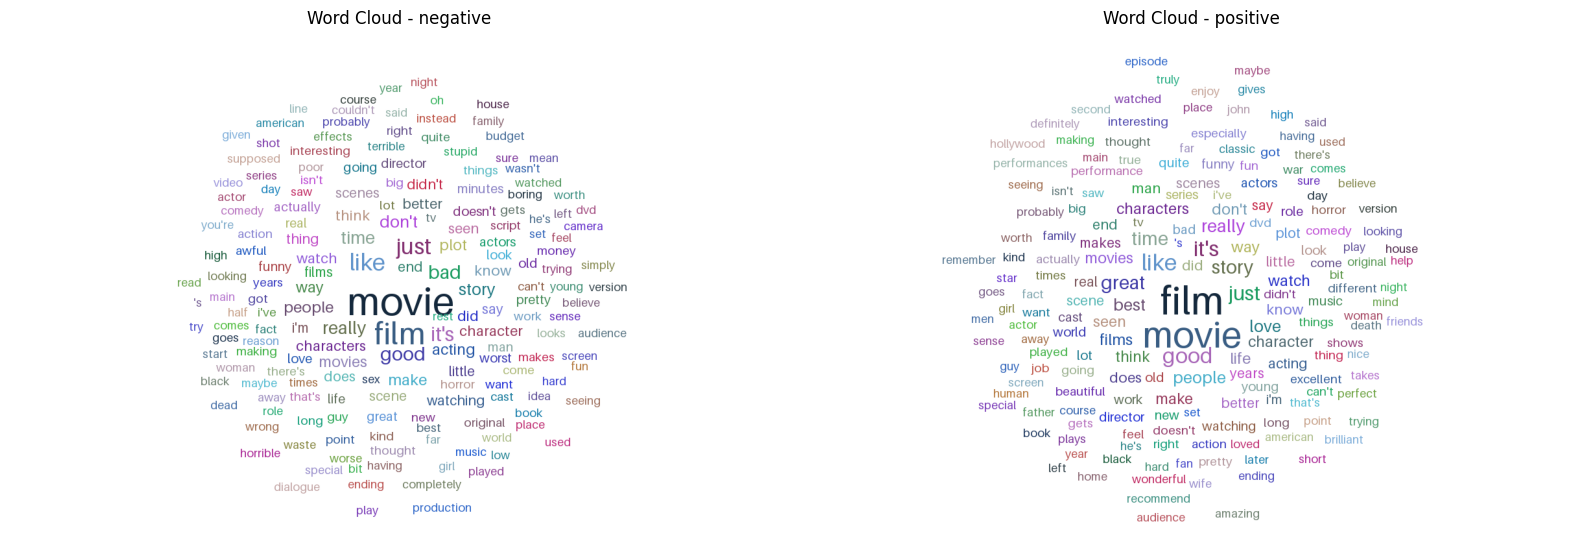

Top-50 từ phổ biến nhất theo từng lớp:

Lớp negative:


,rank,token,count
0,1,movie,49608
1,2,film,36693
2,3,like,22452
3,4,just,21066
4,5,it's,16766
5,6,bad,14669
6,7,good,14669
7,8,really,12352
8,9,time,12323
9,10,don't,10206



Lớp positive:


,rank,token,count
0,1,film,41010
1,2,movie,37457
2,3,like,17709
3,4,it's,16722
4,5,good,14986
5,6,just,14100
6,7,great,12950
7,8,story,12836
8,9,time,12718
9,10,really,10736


Type-Token Ratio (TTR) theo lớp:


,sentiment,unique_tokens,total_tokens,ttr
0,negative,82575,2659301,0.031051
1,positive,86913,2731549,0.031818


In [5]:
# Chuẩn hóa và tách từ
STOPWORDS = set(ENGLISH_STOP_WORDS)
TOKEN_PATTERN = re.compile(r"[a-zA-Z']+")

def preprocess_tokens(text: str) -> list[str]:
    text = re.sub(r'<[^>]+>', ' ', str(text).lower())
    tokens = TOKEN_PATTERN.findall(text)
    return [t for t in tokens if len(t) > 1 and t not in STOPWORDS]

def build_frequency(series: pd.Series) -> Counter:
    freq = Counter()
    for review in series.astype(str):
        freq.update(preprocess_tokens(review))
    return freq

def compute_ttr(freq: Counter) -> tuple[int, int, float]:
    total_tokens = sum(freq.values())
    unique_tokens = len(freq)
    ttr = unique_tokens / total_tokens if total_tokens > 0 else 0.0
    return unique_tokens, total_tokens, ttr

def draw_simple_wordcloud(ax, freq: Counter, title: str, top_n: int = 180):
    width, height = 1200, 800
    image = Image.new('RGB', (width, height), color='white')
    draw = ImageDraw.Draw(image)

    top_words = freq.most_common(top_n)
    if not top_words:
        ax.text(0.5, 0.5, 'No tokens', ha='center', va='center', fontsize=14)
        ax.axis('off')
        ax.set_title(title)
        return

    max_count = top_words[0][1]
    min_count = top_words[-1][1]

    # Dùng font mặc định để đảm bảo chạy trên mọi máy
    font_cache = {}
    occupied = []
    center_x, center_y = width // 2, height // 2

    for i, (word, count) in enumerate(top_words):
        if max_count == min_count:
            size = 26
        else:
            size = int(18 + (count - min_count) * (60 - 18) / (max_count - min_count))

        if size not in font_cache:
            font_cache[size] = ImageFont.load_default(size=size)
        font = font_cache[size]

        bbox = draw.textbbox((0, 0), word, font=font)
        text_w = bbox[2] - bbox[0]
        text_h = bbox[3] - bbox[1]

        placed = False
        # Đặt từ theo quỹ đạo xoắn ốc từ tâm ra ngoài để giảm chồng lấn
        for step in range(1, 2000):
            angle = 0.45 * step + i * 0.17
            radius = 3.2 * step
            x = int(center_x + radius * __import__('math').cos(angle) - text_w / 2)
            y = int(center_y + radius * __import__('math').sin(angle) - text_h / 2)

            if x < 0 or y < 0 or x + text_w >= width or y + text_h >= height:
                continue

            rect = (x - 2, y - 2, x + text_w + 2, y + text_h + 2)
            overlap = False
            for ox1, oy1, ox2, oy2 in occupied:
                if not (rect[2] < ox1 or rect[0] > ox2 or rect[3] < oy1 or rect[1] > oy2):
                    overlap = True
                    break

            if not overlap:
                color = (
                    20 + (i * 37) % 180,
                    40 + (i * 53) % 150,
                    60 + (i * 71) % 160,
                )
                draw.text((x, y), word, fill=color, font=font)
                occupied.append(rect)
                placed = True
                break

        if not placed:
            # Nếu không tìm được vị trí hợp lệ thì bỏ qua từ này
            continue

    ax.imshow(image)
    ax.axis('off')
    ax.set_title(title)

# Tính tần suất từ cho từng lớp
freq_by_class = {
    label: build_frequency(text_stats.loc[text_stats['sentiment'] == label, 'review'])
    for label in sorted(text_stats['sentiment'].unique())
}

# Vẽ word cloud cho từng lớp
fig, axes = plt.subplots(1, len(freq_by_class), figsize=(16, 7))
if len(freq_by_class) == 1:
    axes = [axes]

for ax, label in zip(axes, sorted(freq_by_class.keys())):
    draw_simple_wordcloud(ax, freq_by_class[label], f'Word Cloud - {label}')

plt.tight_layout()
plt.show()

# Tạo 2 bảng top-50 từ phổ biến nhất (mỗi lớp một bảng)
top50_by_class = {}
for label in sorted(freq_by_class.keys()):
    top50 = pd.DataFrame(freq_by_class[label].most_common(50), columns=['token', 'count'])
    top50.insert(0, 'rank', range(1, len(top50) + 1))
    top50_by_class[label] = top50

print('Top-50 từ phổ biến nhất theo từng lớp:')
for label in sorted(top50_by_class.keys()):
    print(f'\nLớp {label}:')
    display(top50_by_class[label])

# Tính TTR cho từng lớp
ttr_rows = []
for label in sorted(freq_by_class.keys()):
    unique_tokens, total_tokens, ttr = compute_ttr(freq_by_class[label])
    ttr_rows.append(
        {
            'sentiment': label,
            'unique_tokens': unique_tokens,
            'total_tokens': total_tokens,
            'ttr': ttr,
        }
    )

ttr_df = pd.DataFrame(ttr_rows).sort_values('sentiment').reset_index(drop=True)
print('Type-Token Ratio (TTR) theo lớp:')
display(ttr_df)

### c. Phân tích phân phối Zipf: vẽ log-log plot của tần suất từ và kiểm tra mức độ tuân theo định luật Zipf.

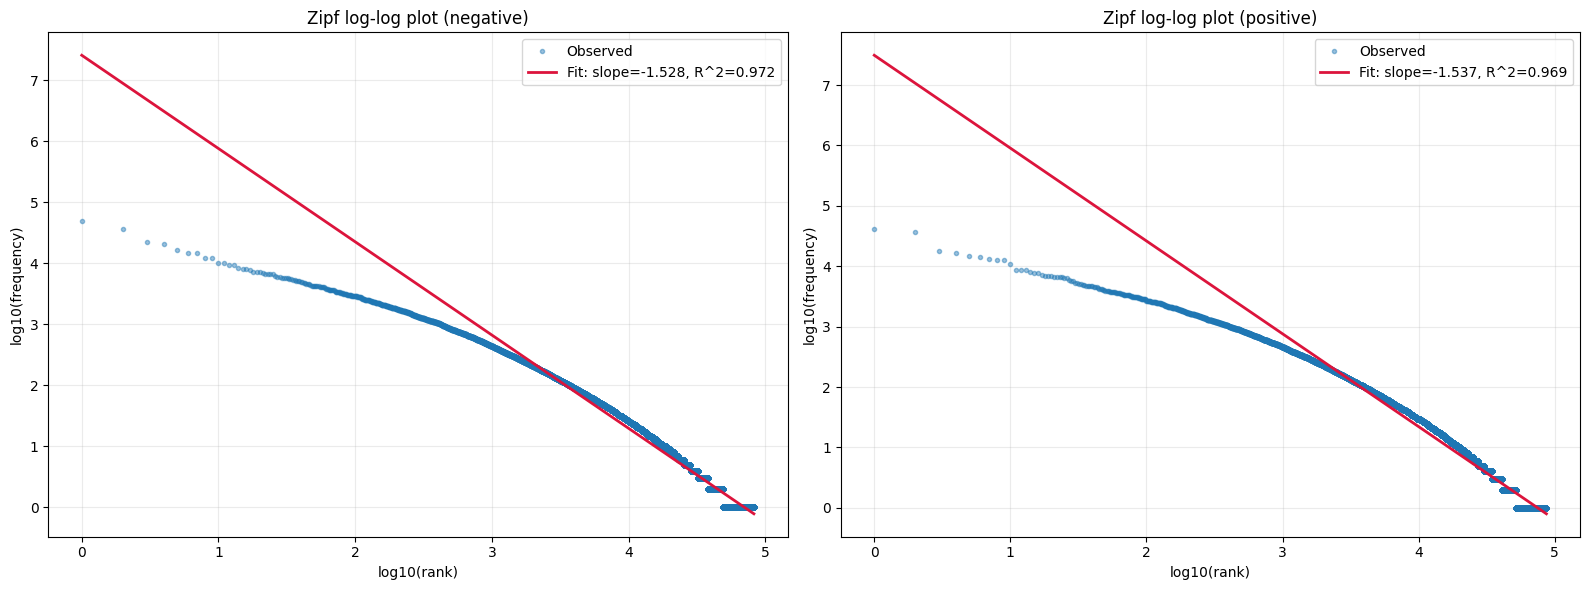

Đánh giá mức độ tuân theo Zipf (tiêu chí: slope gần -1 và R^2 cao):


,sentiment,slope_b,intercept_a,r_squared,n_terms,zipf_like
0,negative,-1.527999,7.408253,0.971787,82575,False
1,positive,-1.537065,7.492453,0.969045,86913,False


- negative: slope=-1.528, R^2=0.972 -> Tuân theo chưa rõ ràng
- positive: slope=-1.537, R^2=0.969 -> Tuân theo chưa rõ ràng


In [6]:
# Đảm bảo có tần suất từ cho từng lớp (nếu Cell 9 chưa chạy)
if 'freq_by_class' not in globals():
    freq_by_class = {
        label: build_frequency(text_stats.loc[text_stats['sentiment'] == label, 'review'])
        for label in sorted(text_stats['sentiment'].unique())
    }

zipf_results = []
fig, axes = plt.subplots(1, len(freq_by_class), figsize=(16, 6))
if len(freq_by_class) == 1:
    axes = [axes]

for ax, label in zip(axes, sorted(freq_by_class.keys())):
    counts = np.array(sorted(freq_by_class[label].values(), reverse=True), dtype=float)
    ranks = np.arange(1, len(counts) + 1, dtype=float)

    log_rank = np.log10(ranks)
    log_freq = np.log10(counts)

    # Hồi quy tuyến tính trên không gian log-log: log(f) = a + b*log(r)
    reg = linregress(log_rank, log_freq)
    fit_log_freq = reg.intercept + reg.slope * log_rank

    ax.plot(log_rank, log_freq, marker='.', linestyle='none', alpha=0.45, label='Observed')
    ax.plot(log_rank, fit_log_freq, color='crimson', linewidth=2,
            label=f'Fit: slope={reg.slope:.3f}, R^2={reg.rvalue**2:.3f}')
    ax.set_title(f'Zipf log-log plot ({label})')
    ax.set_xlabel('log10(rank)')
    ax.set_ylabel('log10(frequency)')
    ax.legend()
    ax.grid(alpha=0.25)

    zipf_results.append(
        {
            'sentiment': label,
            'slope_b': reg.slope,
            'intercept_a': reg.intercept,
            'r_squared': reg.rvalue ** 2,
            'n_terms': int(len(counts)),
            'zipf_like': (abs(reg.slope + 1) <= 0.2) and ((reg.rvalue ** 2) >= 0.95),
        }
    )

plt.tight_layout()
plt.show()

zipf_df = pd.DataFrame(zipf_results).sort_values('sentiment').reset_index(drop=True)
print('Đánh giá mức độ tuân theo Zipf (tiêu chí: slope gần -1 và R^2 cao):')
display(zipf_df)

for row in zipf_df.itertuples(index=False):
    status = 'Tuân theo khá tốt' if row.zipf_like else 'Tuân theo chưa rõ ràng'
    print(
        f"- {row.sentiment}: slope={row.slope_b:.3f}, R^2={row.r_squared:.3f} -> {status}"
    )

## 2. Các kỹ thuật tiền xử lý và phân tích tác động

### a. Pipeline chuẩn hóa văn bản: 
Cài đặt pipeline hoàn chỉnh gồm: chuyển về chữ thường,
loại bỏ HTML/URL/mention/hashtag, loại bỏ ký tự đặc biệt và số (có điều kiện), chuẩn
hóa khoảng trắng. Với mỗi bước, báo cáo tỉ lệ từ vựng thay đổi và tác động đến phân
phối độ dài văn bản.

### Ghi chú đánh giá pipeline

Ta đánh giá từng bước tiền xử lý bằng 2 nhóm chỉ số:

- **Thay đổi từ vựng**: với $V_t$ là tập từ vựng sau bước $t$.
  $$\Delta_{vocab}^{(t)} = \frac{|V_t| - |V_{t-1}|}{|V_{t-1}|} \times 100\%$$
- **Tác động lên phân phối độ dài văn bản**: so sánh trước/sau bằng kiểm định KS 2 mẫu trên số từ và số ký tự.
  $$D = \sup_x |F_{before}(x) - F_{after}(x)|$$

Toàn bộ kết quả số sẽ được **in ra** và đồng thời lưu trong biến Python để kiểm tra lại.

### Kỹ thuật 1: Chuyển về chữ thường (lowercasing)

**Lý thuyết:** Lowercasing giảm biến thể bề mặt của cùng một từ (ví dụ `Film`, `film`, `FILM`), giúp giảm nhiễu và giảm kích thước từ vựng.

**Kỳ vọng:** số lượng từ vựng giảm hoặc giữ nguyên; phân phối độ dài theo ký tự có thể thay đổi nhẹ, còn độ dài theo số từ thường thay đổi rất ít.

[Lowercasing]
- Vocab size: 119370 -> 119370
- Vocab change rate (%): 0.0000
- Mean word length: 231.1569 -> 231.1569 (delta=0.0000)
- Mean char length: 1309.4310 -> 1309.4310 (delta=0.0000)
- Overall KS word_len: D=0.0000, p-value=1
- Overall KS char_len: D=0.0000, p-value=1
KS theo từng lớp:


,sentiment,word_ks_stat,word_ks_pvalue,char_ks_stat,char_ks_pvalue
0,negative,0.0,1.0,0.0,1.0
1,positive,0.0,1.0,0.0,1.0


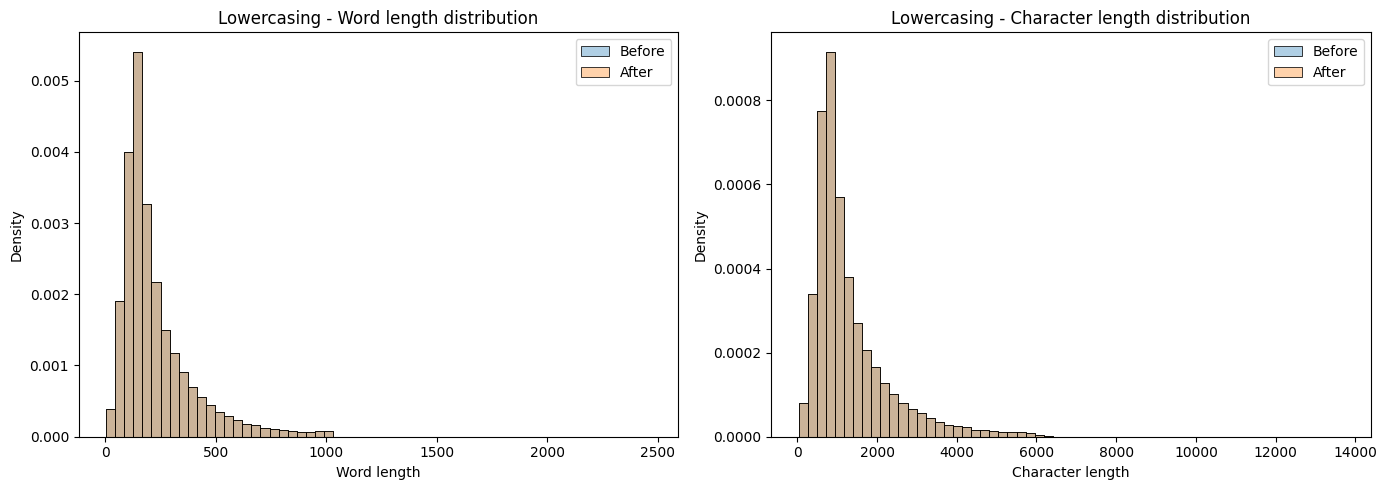

In [7]:
# Khởi tạo dữ liệu làm việc
prep_df = df[['review', 'sentiment']].copy()
prep_df['text_raw'] = prep_df['review'].astype(str)

# Biến tổng hợp kết quả toàn pipeline
preprocess_step_results = {}
preprocess_step_metrics_df = pd.DataFrame()

ANALYSIS_TOKEN_PATTERN = re.compile(r"[a-zA-Z']+")

def extract_tokens_for_vocab(text_series: pd.Series) -> list[str]:
    tokens = []
    for text in text_series.astype(str):
        tokens.extend(ANALYSIS_TOKEN_PATTERN.findall(text.lower()))
    return tokens

def build_text_snapshot(text_series: pd.Series, sentiment_series: pd.Series) -> dict:
    text_series = text_series.astype(str)
    word_len = text_series.str.split().str.len()
    char_len = text_series.str.len()
    tokens = extract_tokens_for_vocab(text_series)
    vocab = set(tokens)

    snapshot = {
        'word_len': word_len,
        'char_len': char_len,
        'vocab_size': len(vocab),
        'token_count': len(tokens),
        'mean_word_len': float(word_len.mean()),
        'mean_char_len': float(char_len.mean()),
        'vocab': vocab,
        'by_class_mean': (
            pd.DataFrame({
                'sentiment': sentiment_series.values,
                'word_len': word_len.values,
                'char_len': char_len.values,
            })
            .groupby('sentiment')[['word_len', 'char_len']]
            .mean()
        ),
    }
    return snapshot

def evaluate_step(prev_col: str, curr_col: str, step_name: str, step_key: str) -> dict:
    prev_snapshot = build_text_snapshot(prep_df[prev_col], prep_df['sentiment'])
    curr_snapshot = build_text_snapshot(prep_df[curr_col], prep_df['sentiment'])

    vocab_change_rate = (
        (curr_snapshot['vocab_size'] - prev_snapshot['vocab_size'])
        / max(prev_snapshot['vocab_size'], 1)
        * 100
    )

    overall_word_ks = ks_2samp(prev_snapshot['word_len'], curr_snapshot['word_len'])
    overall_char_ks = ks_2samp(prev_snapshot['char_len'], curr_snapshot['char_len'])

    ks_rows = []
    for label in sorted(prep_df['sentiment'].unique()):
        prev_mask = prep_df['sentiment'] == label
        curr_mask = prep_df['sentiment'] == label

        word_ks = ks_2samp(
            prev_snapshot['word_len'][prev_mask],
            curr_snapshot['word_len'][curr_mask],
        )
        char_ks = ks_2samp(
            prev_snapshot['char_len'][prev_mask],
            curr_snapshot['char_len'][curr_mask],
        )
        ks_rows.append(
            {
                'sentiment': label,
                'word_ks_stat': float(word_ks.statistic),
                'word_ks_pvalue': float(word_ks.pvalue),
                'char_ks_stat': float(char_ks.statistic),
                'char_ks_pvalue': float(char_ks.pvalue),
            }
        )

    ks_by_class_df = pd.DataFrame(ks_rows)

    metrics = {
        'step_key': step_key,
        'step_name': step_name,
        'prev_col': prev_col,
        'curr_col': curr_col,
        'prev_vocab_size': int(prev_snapshot['vocab_size']),
        'curr_vocab_size': int(curr_snapshot['vocab_size']),
        'vocab_change_rate_pct': float(vocab_change_rate),
        'prev_mean_word_len': float(prev_snapshot['mean_word_len']),
        'curr_mean_word_len': float(curr_snapshot['mean_word_len']),
        'delta_mean_word_len': float(curr_snapshot['mean_word_len'] - prev_snapshot['mean_word_len']),
        'prev_mean_char_len': float(prev_snapshot['mean_char_len']),
        'curr_mean_char_len': float(curr_snapshot['mean_char_len']),
        'delta_mean_char_len': float(curr_snapshot['mean_char_len'] - prev_snapshot['mean_char_len']),
        'overall_word_ks_stat': float(overall_word_ks.statistic),
        'overall_word_ks_pvalue': float(overall_word_ks.pvalue),
        'overall_char_ks_stat': float(overall_char_ks.statistic),
        'overall_char_ks_pvalue': float(overall_char_ks.pvalue),
    }

    result = {
        'metrics': metrics,
        'ks_by_class_df': ks_by_class_df,
        'prev_snapshot': prev_snapshot,
        'curr_snapshot': curr_snapshot,
    }
    preprocess_step_results[step_key] = result

    # In kết quả số
    print(f'[{step_name}]')
    print(f"- Vocab size: {metrics['prev_vocab_size']} -> {metrics['curr_vocab_size']}")
    print(f"- Vocab change rate (%): {metrics['vocab_change_rate_pct']:.4f}")
    print(
        f"- Mean word length: {metrics['prev_mean_word_len']:.4f} -> {metrics['curr_mean_word_len']:.4f} "
        f"(delta={metrics['delta_mean_word_len']:.4f})"
    )
    print(
        f"- Mean char length: {metrics['prev_mean_char_len']:.4f} -> {metrics['curr_mean_char_len']:.4f} "
        f"(delta={metrics['delta_mean_char_len']:.4f})"
    )
    print(
        f"- Overall KS word_len: D={metrics['overall_word_ks_stat']:.4f}, "
        f"p-value={metrics['overall_word_ks_pvalue']:.4g}"
    )
    print(
        f"- Overall KS char_len: D={metrics['overall_char_ks_stat']:.4f}, "
        f"p-value={metrics['overall_char_ks_pvalue']:.4g}"
    )
    print('KS theo từng lớp:')
    display(ks_by_class_df)

    # Vẽ tác động phân phối độ dài trước/sau
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(prev_snapshot['word_len'], bins=60, stat='density', alpha=0.35, ax=axes[0], label='Before')
    sns.histplot(curr_snapshot['word_len'], bins=60, stat='density', alpha=0.35, ax=axes[0], label='After')
    axes[0].set_title(f'{step_name} - Word length distribution')
    axes[0].set_xlabel('Word length')
    axes[0].set_ylabel('Density')
    axes[0].legend()

    sns.histplot(prev_snapshot['char_len'], bins=60, stat='density', alpha=0.35, ax=axes[1], label='Before')
    sns.histplot(curr_snapshot['char_len'], bins=60, stat='density', alpha=0.35, ax=axes[1], label='After')
    axes[1].set_title(f'{step_name} - Character length distribution')
    axes[1].set_xlabel('Character length')
    axes[1].set_ylabel('Density')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return result

# Bước 1: lowercasing
prep_df['text_step1_lower'] = prep_df['text_raw'].str.lower()
step1_result = evaluate_step('text_raw', 'text_step1_lower', 'Lowercasing', 'step1_lower')
step1_metrics = step1_result['metrics']
step1_ks_by_class_df = step1_result['ks_by_class_df']

**Phân tích kết quả kỹ thuật 1**

Quan sát các biến `step1_metrics` và `step1_ks_by_class_df`:

- Nếu `vocab_change_rate_pct < 0` thì lowercasing đã giảm số biến thể từ vựng.
- Nếu `overall_word_ks_pvalue` lớn, phân phối số từ ít thay đổi; điều này thường đúng vì lowercasing không tách/gộp token theo khoảng trắng.
- Mức thay đổi chính thường nằm ở độ dài ký tự (nhỏ) do chuẩn hóa chữ hoa/thường, thể hiện qua `overall_char_ks_stat` và `overall_char_ks_pvalue`.

### Kỹ thuật 2: Loại bỏ HTML / URL / mention / hashtag

**Lý thuyết:** Các thành phần cấu trúc web hoặc mạng xã hội thường không mang nhiều tín hiệu ngữ nghĩa cho bài toán sentiment chuẩn.

Ta áp dụng các mẫu regex để loại bỏ:

- HTML tags: `<...>`
- URL: `http...`, `www...`
- Mention: `@username`
- Hashtag marker: ký tự `#` (giữ lại nội dung chữ sau dấu `#` nếu có)

[Remove HTML/URL/Mention/Hashtag]
- Vocab size: 119370 -> 119224
- Vocab change rate (%): -0.1223
- Mean word length: 231.1569 -> 228.8652 (delta=-2.2918)
- Mean char length: 1309.4310 -> 1289.0708 (delta=-20.3602)
- Overall KS word_len: D=0.0075, p-value=0.1177
- Overall KS char_len: D=0.0119, p-value=0.001709
KS theo từng lớp:


,sentiment,word_ks_stat,word_ks_pvalue,char_ks_stat,char_ks_pvalue
0,negative,0.00844,0.333528,0.01320,0.025432
1,positive,0.00692,0.585025,0.01124,0.084340


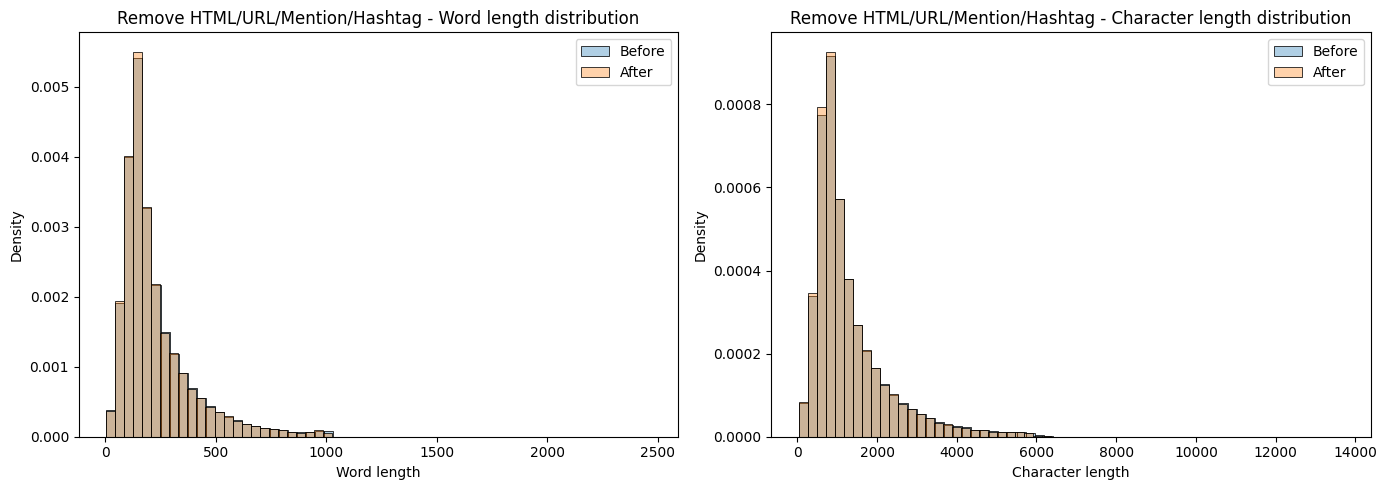

In [8]:
def remove_html_url_mention_hashtag(text: str) -> str:
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#', ' ', text)
    return text

prep_df['text_step2_no_web'] = prep_df['text_step1_lower'].apply(remove_html_url_mention_hashtag)
step2_result = evaluate_step('text_step1_lower', 'text_step2_no_web', 'Remove HTML/URL/Mention/Hashtag', 'step2_no_web')
step2_metrics = step2_result['metrics']
step2_ks_by_class_df = step2_result['ks_by_class_df']

**Phân tích kết quả kỹ thuật 2**

Dựa trên `step2_metrics` và `step2_ks_by_class_df`:

- `vocab_change_rate_pct` âm cho thấy các token liên quan HTML/URL/mention đã được loại bỏ khỏi từ vựng.
- Nếu `overall_char_ks_stat` tăng rõ hơn `overall_word_ks_stat`, bước này chủ yếu rút ngắn độ dài ký tự do xóa URL dài.
- So sánh theo lớp trong `step2_ks_by_class_df` giúp kiểm tra lớp nào chịu tác động mạnh hơn.

### Kỹ thuật 3: Loại bỏ ký tự đặc biệt và số (có điều kiện)

**Lý thuyết:** chuẩn hóa ký tự giúp giảm nhiễu token. Tuy nhiên số có thể chứa thông tin (ví dụ `10/10`, `2024`) nên ta chỉ xóa **số đứng độc lập**.

Quy tắc áp dụng:

- Xóa số độc lập bằng regex `\b\d+\b`.
- Xóa ký tự đặc biệt, chỉ giữ chữ cái tiếng Anh, dấu nháy đơn và khoảng trắng.

[Remove special chars + conditional numbers]
- Vocab size: 119224 -> 119224
- Vocab change rate (%): 0.0000
- Mean word length: 228.8652 -> 229.7421 (delta=0.8769)
- Mean char length: 1289.0708 -> 1287.6049 (delta=-1.4659)
- Overall KS word_len: D=0.0039, p-value=0.8445
- Overall KS char_len: D=0.0014, p-value=1
KS theo từng lớp:


,sentiment,word_ks_stat,word_ks_pvalue,char_ks_stat,char_ks_pvalue
0,negative,0.00444,0.965280,0.00160,1.0
1,positive,0.00480,0.934228,0.00164,1.0


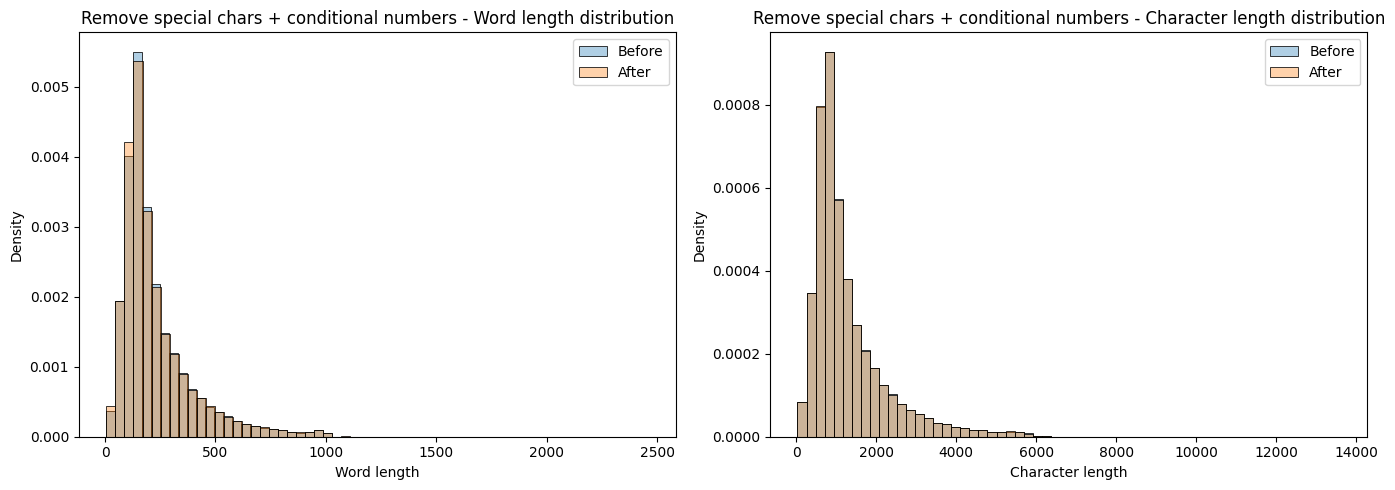

In [9]:
def remove_special_and_conditional_numbers(text: str) -> str:
    text = re.sub(r'\b\d+\b', ' ', text)
    text = re.sub(r"[^a-zA-Z'\s]", ' ', text)
    return text

prep_df['text_step3_clean_chars'] = prep_df['text_step2_no_web'].apply(remove_special_and_conditional_numbers)
step3_result = evaluate_step(
    'text_step2_no_web',
    'text_step3_clean_chars',
    'Remove special chars + conditional numbers',
    'step3_clean_chars',
)
step3_metrics = step3_result['metrics']
step3_ks_by_class_df = step3_result['ks_by_class_df']

**Phân tích kết quả kỹ thuật 3**

Đánh giá `step3_metrics` và `step3_ks_by_class_df`:

- Nếu `vocab_change_rate_pct` giảm mạnh, bước này đã loại bỏ nhiều token nhiễu (ký tự đặc biệt/số).
- `delta_mean_char_len` âm thường rõ rệt vì ký tự không chữ bị xóa.
- Dựa vào `overall_word_ks_pvalue` và `overall_char_ks_pvalue` để kiểm tra mức thay đổi phân phối có ý nghĩa thống kê hay không.

### Kỹ thuật 4: Chuẩn hóa khoảng trắng

**Lý thuyết:** sau khi xóa nhiều thành phần (URL, ký tự đặc biệt...), văn bản thường có nhiều khoảng trắng dư thừa. Chuẩn hóa giúp biểu diễn văn bản nhất quán.

Phép chuẩn hóa:

$$x' = \operatorname{strip}\left(\operatorname{regex\_replace}(x, \text{"\\s+"}, \text{" "})\right)$$

trong đó mọi chuỗi khoảng trắng liên tiếp được thay bằng 1 khoảng trắng đơn.

[Whitespace normalization]
- Vocab size: 119224 -> 119224
- Vocab change rate (%): 0.0000
- Mean word length: 229.7421 -> 229.7421 (delta=0.0000)
- Mean char length: 1287.6049 -> 1249.0562 (delta=-38.5487)
- Overall KS word_len: D=0.0000, p-value=1
- Overall KS char_len: D=0.0291, p-value=7.512e-19
KS theo từng lớp:


,sentiment,word_ks_stat,word_ks_pvalue,char_ks_stat,char_ks_pvalue
0,negative,0.0,1.0,0.03072,1.106300e-10
1,positive,0.0,1.0,0.02848,3.053736e-09


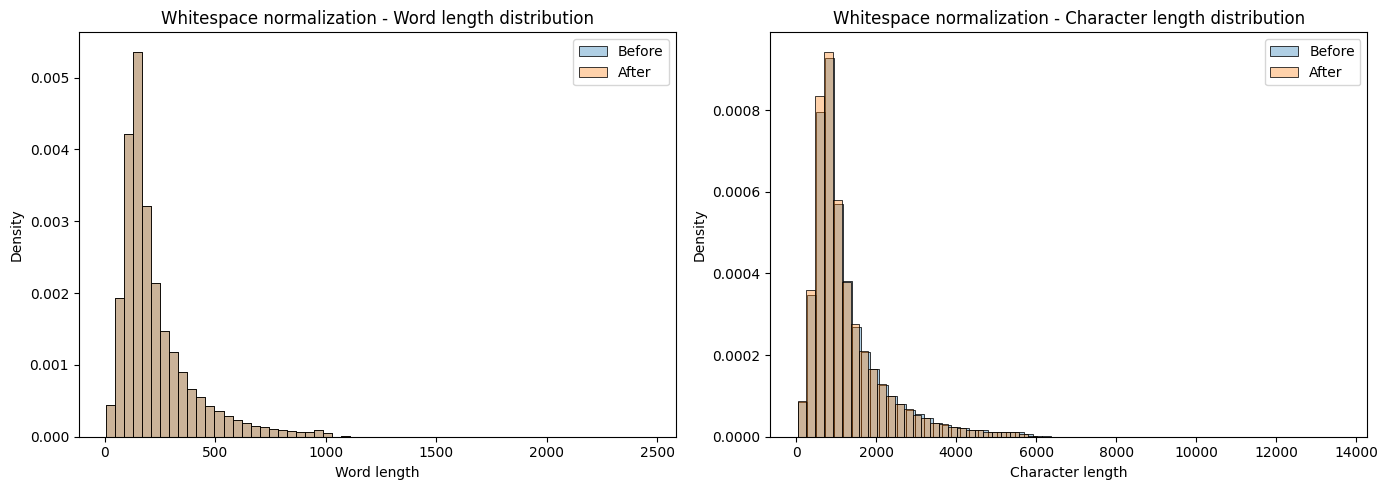

Bảng tổng hợp chỉ số pipeline (đã lưu trong preprocess_step_metrics_df):


,step_key,step_name,prev_col,curr_col,prev_vocab_size,curr_vocab_size,vocab_change_rate_pct,prev_mean_word_len,curr_mean_word_len,delta_mean_word_len,prev_mean_char_len,curr_mean_char_len,delta_mean_char_len,overall_word_ks_stat,overall_word_ks_pvalue,overall_char_ks_stat,overall_char_ks_pvalue
0,step1_lower,Lowercasing,text_raw,text_step1_lower,119370,119370,0.000000,231.15694,231.15694,0.00000,1309.43102,1309.43102,0.00000,0.00000,1.000000,0.00000,1.000000e+00
1,step2_no_web,Remove HTML/URL/Mention/Hashtag,text_step1_lower,text_step2_no_web,119370,119224,-0.122309,231.15694,228.86516,-2.29178,1309.43102,1289.07080,-20.36022,0.00752,0.117702,0.01188,1.709334e-03
2,step3_clean_chars,Remove special chars + conditional numbers,text_step2_no_web,text_step3_clean_chars,119224,119224,0.000000,228.86516,229.74208,0.87692,1289.07080,1287.60492,-1.46588,0.00388,0.844476,0.00138,1.000000e+00
3,step4_norm_space,Whitespace normalization,text_step3_clean_chars,text_step4_norm_space,119224,119224,0.000000,229.74208,229.74208,0.00000,1287.60492,1249.05624,-38.54868,0.00000,1.000000,0.02912,7.512057e-19



Tóm tắt nhanh các biến kết quả chính:
preprocess_vocab_change_rates = {'step1_lower': 0.0, 'step2_no_web': -0.12230878780263048, 'step3_clean_chars': 0.0, 'step4_norm_space': 0.0}
preprocess_overall_word_ks_pvalues = {'step1_lower': 1.0, 'step2_no_web': 0.11770185425613888, 'step3_clean_chars': 0.8444759423146997, 'step4_norm_space': 1.0}
preprocess_overall_char_ks_pvalues = {'step1_lower': 1.0, 'step2_no_web': 0.0017093335054648925, 'step3_clean_chars': 0.9999999999185027, 'step4_norm_space': 7.51205657904977e-19}


In [10]:
def normalize_whitespace(text: str) -> str:
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

prep_df['text_step4_norm_space'] = prep_df['text_step3_clean_chars'].apply(normalize_whitespace)
step4_result = evaluate_step(
    'text_step3_clean_chars',
    'text_step4_norm_space',
    'Whitespace normalization',
    'step4_norm_space',
)
step4_metrics = step4_result['metrics']
step4_ks_by_class_df = step4_result['ks_by_class_df']

# Tổng hợp toàn bộ chỉ số theo từng bước
preprocess_step_metrics_df = pd.DataFrame([
    step1_metrics,
    step2_metrics,
    step3_metrics,
    step4_metrics,
])

preprocess_vocab_change_rates = {
    row['step_key']: row['vocab_change_rate_pct']
    for row in preprocess_step_metrics_df.to_dict('records')
}
preprocess_overall_word_ks_pvalues = {
    row['step_key']: row['overall_word_ks_pvalue']
    for row in preprocess_step_metrics_df.to_dict('records')
}
preprocess_overall_char_ks_pvalues = {
    row['step_key']: row['overall_char_ks_pvalue']
    for row in preprocess_step_metrics_df.to_dict('records')
}

print('Bảng tổng hợp chỉ số pipeline (đã lưu trong preprocess_step_metrics_df):')
display(preprocess_step_metrics_df)

print('\nTóm tắt nhanh các biến kết quả chính:')
print('preprocess_vocab_change_rates =', preprocess_vocab_change_rates)
print('preprocess_overall_word_ks_pvalues =', preprocess_overall_word_ks_pvalues)
print('preprocess_overall_char_ks_pvalues =', preprocess_overall_char_ks_pvalues)

**Phân tích kết quả kỹ thuật 4 và toàn pipeline**

Dựa trên `step4_metrics` và `preprocess_step_metrics_df`:

- `vocab_change_rate_pct` ở bước 4 thường nhỏ vì chuẩn hóa khoảng trắng chủ yếu làm sạch biểu diễn, không thay đổi nhiều token.
- So sánh các dòng trong `preprocess_step_metrics_df` để xác định bước nào tác động mạnh nhất lên phân phối độ dài (dựa trên KS statistic/p-value).
- Có thể dùng `preprocess_vocab_change_rates` để kết luận bước làm giảm từ vựng nhiều nhất, và dùng `preprocess_overall_word_ks_pvalues`, `preprocess_overall_char_ks_pvalues` để kiểm tra ý nghĩa thống kê của thay đổi phân phối.

### b. So sánh chiến lược tokenization: 
Cài đặt và so sánh 4 chiến lược: word-level (NLTK,
spaCy), sentence-level, character-level, và subword (BPE bằng thư viện tokenizers
của HuggingFace). Với mỗi chiến lược, báo cáo: (i) kích thước từ vựng; (ii) tỉ lệ OOV
(out-of-vocabulary) trên tập test; (iii) độ dài chuỗi token trung bình.

**Lý thuyết và công thức đánh giá tokenization**

Giả sử $\mathcal{D}_{train}$ là tập huấn luyện, $\mathcal{D}_{test}$ là tập kiểm tra, và hàm tokenization là $T(\cdot)$.

- **(i) Kích thước từ vựng**
  Với từ vựng học từ train:
  $$V_{train} = \bigcup_{x \in \mathcal{D}_{train}} T(x), \quad |V_{train}|$$

- **(ii) Tỉ lệ OOV trên test**
  Với tập token test $\{t_i\}_{i=1}^{N_{test}}$:
  $$\mathrm{OOV\ Rate} = \frac{1}{N_{test}} \sum_{i=1}^{N_{test}} \mathbf{1}[t_i \notin V_{train}]$$
  Riêng với BPE, OOV được đo bằng tỉ lệ token ánh xạ về `[UNK]`.

- **(iii) Độ dài chuỗi token trung bình trên test**
  Với $L_j = |T(x_j)|,\ x_j \in \mathcal{D}_{test}$:
  $$\overline{L} = \frac{1}{|\mathcal{D}_{test}|} \sum_j L_j$$

Các chiến lược so sánh: word-level (NLTK, spaCy), sentence-level, character-level và subword BPE (HuggingFace tokenizers).

In [11]:
# Chọn cột văn bản để so sánh tokenization: ưu tiên văn bản đã chuẩn hóa
if 'prep_df' in globals() and 'text_step4_norm_space' in prep_df.columns:
    tokenization_text_col = 'text_step4_norm_space'
    tokenization_df = prep_df[['sentiment', tokenization_text_col]].copy()
else:
    tokenization_text_col = 'review'
    tokenization_df = df[['sentiment', tokenization_text_col]].copy()
    tokenization_df[tokenization_text_col] = tokenization_df[tokenization_text_col].astype(str).str.lower()

tokenization_df = tokenization_df.rename(columns={tokenization_text_col: 'text'})
tokenization_df['text'] = tokenization_df['text'].astype(str)

train_texts, test_texts = train_test_split(
    tokenization_df['text'].tolist(),
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=tokenization_df['sentiment'].tolist(),
)

def safe_sentence_tokenize(text: str) -> list[str]:
    try:
        return [s for s in nltk.sent_tokenize(text) if s.strip()]
    except LookupError:
        try:
            nltk.download('punkt', quiet=True)
            return [s for s in nltk.sent_tokenize(text) if s.strip()]
        except Exception:
            # Fallback khi punkt không khả dụng
            return [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if s.strip()]

def word_nltk_tokenize(text: str) -> list[str]:
    return [tok for tok in nltk.wordpunct_tokenize(text) if tok.strip()]

nlp_spacy = spacy.blank('en')
def word_spacy_tokenize(text: str) -> list[str]:
    return [tok.text for tok in nlp_spacy.tokenizer(text) if tok.text.strip()]

def sentence_level_tokenize(text: str) -> list[str]:
    return safe_sentence_tokenize(text)

def character_level_tokenize(text: str) -> list[str]:
    return list(text)

# Huấn luyện tokenizer BPE trên tập train
bpe_tokenizer = Tokenizer(BPE(unk_token='[UNK]'))
bpe_tokenizer.pre_tokenizer = Whitespace()
bpe_trainer = BpeTrainer(vocab_size=8000, special_tokens=['[UNK]', '[PAD]'])
bpe_tokenizer.train_from_iterator(train_texts, trainer=bpe_trainer)
bpe_unk_id = bpe_tokenizer.token_to_id('[UNK]')

def subword_bpe_tokenize(text: str) -> list[str]:
    return bpe_tokenizer.encode(text).tokens

tokenization_strategies = {
    'word_nltk': word_nltk_tokenize,
    'word_spacy': word_spacy_tokenize,
    'sentence_level': sentence_level_tokenize,
    'character_level': character_level_tokenize,
    'subword_bpe': subword_bpe_tokenize,
}

tokenization_results = {}
tokenization_comparison_rows = []

for strategy_name, tokenizer_fn in tokenization_strategies.items():
    train_tokens_by_doc = [tokenizer_fn(text) for text in train_texts]
    test_tokens_by_doc = [tokenizer_fn(text) for text in test_texts]

    train_vocab = set(tok for toks in train_tokens_by_doc for tok in toks)
    test_all_tokens = [tok for toks in test_tokens_by_doc for tok in toks]
    test_token_count = len(test_all_tokens)

    if strategy_name == 'subword_bpe':
        test_encodings = [bpe_tokenizer.encode(text) for text in test_texts]
        oov_count = sum(
            1
            for enc in test_encodings
            for token_id in enc.ids
            if token_id == bpe_unk_id
        )
    else:
        oov_count = sum(1 for tok in test_all_tokens if tok not in train_vocab)

    oov_rate = oov_count / test_token_count if test_token_count > 0 else 0.0
    avg_token_length = float(np.mean([len(toks) for toks in test_tokens_by_doc])) if test_tokens_by_doc else 0.0

    metrics = {
        'strategy': strategy_name,
        'vocab_size': int(len(train_vocab)),
        'oov_count_test': int(oov_count),
        'oov_rate_test': float(oov_rate),
        'avg_sequence_len_test': float(avg_token_length),
        'n_test_docs': int(len(test_tokens_by_doc)),
        'n_test_tokens': int(test_token_count),
    }
    tokenization_results[strategy_name] = metrics
    tokenization_comparison_rows.append(metrics)

tokenization_comparison_df = pd.DataFrame(tokenization_comparison_rows).sort_values('strategy').reset_index(drop=True)

print('Bảng so sánh chiến lược tokenization:')
display(tokenization_comparison_df)

print('\nBiến kết quả để kiểm tra lại:')
print('- tokenization_results (dict theo chiến lược)')
print('- tokenization_comparison_df (DataFrame tổng hợp)')
print('- bpe_tokenizer (mô hình BPE đã huấn luyện trên train)')

Bảng so sánh chiến lược tokenization:


,strategy,vocab_size,oov_count_test,oov_rate_test,avg_sequence_len_test,n_test_docs,n_test_tokens
0,character_level,28,0,0.000000,1244.3665,10000,12443665
1,sentence_level,39726,9863,0.986300,1.0000,10000,10000
2,subword_bpe,7975,0,0.000000,267.3752,10000,2673752
3,word_nltk,90399,10809,0.004532,238.5250,10000,2385250
4,word_spacy,90855,10924,0.004668,234.0035,10000,2340035



Biến kết quả để kiểm tra lại:
- tokenization_results (dict theo chiến lược)
- tokenization_comparison_df (DataFrame tổng hợp)
- bpe_tokenizer (mô hình BPE đã huấn luyện trên train)


**Phân tích kết quả tokenization**

Đọc kết quả trong `tokenization_comparison_df` theo 3 tiêu chí chính:

- `vocab_size`: kích thước từ vựng học từ tập train; mức lớn thường đi kèm biểu diễn chi tiết hơn.
- `oov_rate_test`: tỉ lệ token test không thuộc từ vựng train (với BPE là tỉ lệ token ánh xạ về `[UNK]`). Giá trị càng thấp càng tốt.
- `avg_sequence_len_test`: độ dài chuỗi token trung bình trên tập test; tokenization càng mịn (character/subword) thì chuỗi thường dài hơn.

Các biến số đã được lưu để tái sử dụng: `tokenization_results`, `tokenization_comparison_df`, `bpe_tokenizer`.

### c. Loại bỏ stop words và phân tích thông tin: 
Loại bỏ stop words và so sánh: (i) kích
thước từ vựng trước/sau; (ii) MI (Mutual Information) trung bình giữa từ và nhãn
trước/sau; (iii) hiệu năng Naive Bayes trước/sau. Thảo luận liệu việc loại bỏ stop
words có luôn cải thiện kết quả không.

**Lý thuyết và công thức đánh giá tác động stop words**

Gọi $V_{before}, V_{after}$ là từ vựng trước/sau khi loại stop words.

- **(i) Kích thước từ vựng**: so sánh $|V_{before}|$ và $|V_{after}|$.

- **(ii) MI trung bình giữa từ và nhãn**: với biến chỉ báo từ $w$ và nhãn $Y$,
  $$I(w;Y)=\sum_{w\in\{0,1\}}\sum_y p(w,y)\log\frac{p(w,y)}{p(w)p(y)}$$
  và trung bình trên toàn bộ từ vựng:
  $$\overline{I}=\frac{1}{|V|}\sum_{w\in V} I(w;Y).$$

- **(iii) Hiệu năng Naive Bayes**: huấn luyện cùng một mô hình MultinomialNB trên đặc trưng BoW trước/sau khi loại stop words, so sánh các chỉ số như Accuracy và Macro-F1 trên tập test cố định.

Lưu ý: loại stop words có thể giảm nhiễu, nhưng cũng có thể làm mất từ chức năng mang tín hiệu ngữ nghĩa trong một số ngữ cảnh.

In [12]:
# Chọn văn bản gốc để so sánh before/after stop words
if 'prep_df' in globals() and 'text_step4_norm_space' in prep_df.columns:
    sw_texts = prep_df['text_step4_norm_space'].astype(str).tolist()
    sw_labels = prep_df['sentiment'].astype(str).tolist()
else:
    sw_texts = df['review'].astype(str).str.lower().tolist()
    sw_labels = df['sentiment'].astype(str).tolist()

X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(
    sw_texts,
    sw_labels,
    test_size=0.2,
    random_state=42,
    stratify=sw_labels,
    shuffle=True,
 )

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_txt)
y_test = label_encoder.transform(y_test_txt)

# Before: không loại stop words
vectorizer_before = CountVectorizer(stop_words=None)
X_train_before = vectorizer_before.fit_transform(X_train_txt)
X_test_before = vectorizer_before.transform(X_test_txt)

# After: loại stop words tiếng Anh
vectorizer_after = CountVectorizer(stop_words='english')
X_train_after = vectorizer_after.fit_transform(X_train_txt)
X_test_after = vectorizer_after.transform(X_test_txt)

vocab_size_before = int(len(vectorizer_before.vocabulary_))
vocab_size_after = int(len(vectorizer_after.vocabulary_))

# MI trung bình trên tập train
mi_before = mutual_info_classif(X_train_before, y_train, discrete_features=True, random_state=42)
mi_after = mutual_info_classif(X_train_after, y_train, discrete_features=True, random_state=42)
mi_mean_before = float(np.mean(mi_before))
mi_mean_after = float(np.mean(mi_after))

# Naive Bayes trước/sau
nb_before = MultinomialNB()
nb_before.fit(X_train_before, y_train)
y_pred_before = nb_before.predict(X_test_before)

nb_after = MultinomialNB()
nb_after.fit(X_train_after, y_train)
y_pred_after = nb_after.predict(X_test_after)

acc_before = float(accuracy_score(y_test, y_pred_before))
acc_after = float(accuracy_score(y_test, y_pred_after))
f1_before = float(f1_score(y_test, y_pred_before, average='macro'))
f1_after = float(f1_score(y_test, y_pred_after, average='macro'))

stopword_comparison_results = {
    'vocab_size_before': vocab_size_before,
    'vocab_size_after': vocab_size_after,
    'vocab_change_pct': float((vocab_size_after - vocab_size_before) / max(vocab_size_before, 1) * 100),
    'mi_mean_before': mi_mean_before,
    'mi_mean_after': mi_mean_after,
    'mi_mean_change_pct': float((mi_mean_after - mi_mean_before) / max(abs(mi_mean_before), 1e-12) * 100),
    'nb_accuracy_before': acc_before,
    'nb_accuracy_after': acc_after,
    'nb_accuracy_delta': float(acc_after - acc_before),
    'nb_macro_f1_before': f1_before,
    'nb_macro_f1_after': f1_after,
    'nb_macro_f1_delta': float(f1_after - f1_before),
}

stopword_comparison_df = pd.DataFrame([
    {
        'setting': 'before_stopword_removal',
        'vocab_size': vocab_size_before,
        'mi_mean': mi_mean_before,
        'nb_accuracy': acc_before,
        'nb_macro_f1': f1_before,
    },
    {
        'setting': 'after_stopword_removal',
        'vocab_size': vocab_size_after,
        'mi_mean': mi_mean_after,
        'nb_accuracy': acc_after,
        'nb_macro_f1': f1_after,
    },
])

print('Kết quả so sánh stop words (số liệu chính):')
print(stopword_comparison_results)
display(stopword_comparison_df)

# In chi tiết để dễ kiểm tra lại
print('\nChi tiết thay đổi:')
print(f"- Vocab: {vocab_size_before} -> {vocab_size_after}")
print(f"- MI mean: {mi_mean_before:.6f} -> {mi_mean_after:.6f}")
print(f"- NB Accuracy: {acc_before:.6f} -> {acc_after:.6f}")
print(f"- NB Macro-F1: {f1_before:.6f} -> {f1_after:.6f}")

Kết quả so sánh stop words (số liệu chính):
{'vocab_size_before': 90370, 'vocab_size_after': 90059, 'vocab_change_pct': -0.3441407546752241, 'mi_mean_before': 5.890971561244957e-05, 'mi_mean_after': 5.558723639369823e-05, 'mi_mean_change_pct': -5.639951210440384, 'nb_accuracy_before': 0.8503, 'nb_accuracy_after': 0.8611, 'nb_accuracy_delta': 0.010800000000000032, 'nb_macro_f1_before': 0.8501417121834938, 'nb_macro_f1_after': 0.8610245516188284, 'nb_macro_f1_delta': 0.010882839435334635}


,setting,vocab_size,mi_mean,nb_accuracy,nb_macro_f1
0,before_stopword_removal,90370,0.000059,0.8503,0.850142
1,after_stopword_removal,90059,0.000056,0.8611,0.861025



Chi tiết thay đổi:
- Vocab: 90370 -> 90059
- MI mean: 0.000059 -> 0.000056
- NB Accuracy: 0.850300 -> 0.861100
- NB Macro-F1: 0.850142 -> 0.861025


**Phân tích và thảo luận**

Dựa trên `stopword_comparison_results` và `stopword_comparison_df`:

- Nếu `vocab_size` giảm mạnh nhưng `nb_accuracy` hoặc `nb_macro_f1` không tăng, điều đó cho thấy giảm chiều không gian không đồng nghĩa với tăng hiệu năng.
- Nếu `mi_mean` tăng sau khi loại stop words, nhiều khả năng đặc trưng còn lại mang thông tin phân biệt lớp tốt hơn trung bình.
- Nếu `mi_mean` hoặc hiệu năng giảm, stop words đang chứa tín hiệu ngữ cảnh hữu ích cho bài toán sentiment này.

Kết luận quan trọng: **loại bỏ stop words không phải lúc nào cũng cải thiện kết quả**. Tác động phụ thuộc dữ liệu, cách tokenization, mô hình học máy và mục tiêu đánh giá.

### d. Stemming, Lemmatization và so sánh định lượng: 
Cài đặt Porter Stemmer, Snowball
Stemmer và WordNet Lemmatizer. Tính collision rate (tỉ lệ các từ khác nhau bị map
về cùng một dạng gốc) cho mỗi phương pháp. Đánh giá tác động đến hiệu năng phân
loại (Logistic Regression, 5-fold CV).

**Lý thuyết và công thức đánh giá**

**Mục tiêu:** so sánh 3 phương pháp chuẩn hóa từ: Porter Stemmer, Snowball Stemmer và WordNet Lemmatizer.

Gọi $V$ là tập từ vựng gốc (các token khác nhau), và $f: V \rightarrow V'$ là phép chuẩn hóa (stem/lemma).

- **Collision rate** đo mức nhiều từ khác nhau bị gộp về cùng một dạng:
  $$\mathrm{Collision\ Rate} = \frac{|V| - |f(V)|}{|V|}$$
  Giá trị càng cao nghĩa là mức gộp càng mạnh.

- **Tác động phân loại**: dùng Logistic Regression với 5-fold cross-validation trên cùng cấu hình vectorizer để so sánh công bằng giữa các phương pháp.

In [13]:
# Cau hinh de can bang giua toc do va do tin cay
STEM_LEMMA_USE_FULL_DATA = False
STEM_LEMMA_SAMPLE_SIZE = 20000
STEM_LEMMA_RANDOM_STATE = 42

STEM_LEMMA_MAX_FEATURES = 30000
STEM_LEMMA_MIN_DF = 3

def ensure_nltk_resource(resource_name: str, download_name: str):
    try:
        nltk.data.find(resource_name)
    except LookupError:
        nltk.download(download_name, quiet=True)

ensure_nltk_resource('corpora/wordnet', 'wordnet')
ensure_nltk_resource('corpora/omw-1.4', 'omw-1.4')

porter = PorterStemmer()
snowball = SnowballStemmer('english')
lemmatizer = WordNetLemmatizer()
TOKEN_PATTERN_LOCAL = re.compile(r"[a-zA-Z']+")

def base_tokenize(text: str) -> list[str]:
    return TOKEN_PATTERN_LOCAL.findall(str(text).lower())

def normalize_tokens(tokens: list[str], method: str) -> list[str]:
    if method == 'porter':
        return [porter.stem(t) for t in tokens]
    if method == 'snowball':
        return [snowball.stem(t) for t in tokens]
    if method == 'wordnet_lemma':
        return [lemmatizer.lemmatize(t) for t in tokens]
    if method == 'baseline':
        return tokens
    raise ValueError(f'Unknown method: {method}')

# Chon du lieu nen
if 'prep_df' in globals() and 'text_step4_norm_space' in prep_df.columns:
    sl_texts_all = prep_df['text_step4_norm_space'].astype(str).tolist()
    sl_labels_all = prep_df['sentiment'].astype(str).tolist()
else:
    sl_texts_all = df['review'].astype(str).str.lower().tolist()
    sl_labels_all = df['sentiment'].astype(str).tolist()

# Giam tai neu khong can chay full
if STEM_LEMMA_USE_FULL_DATA or len(sl_texts_all) <= STEM_LEMMA_SAMPLE_SIZE:
    sl_texts = sl_texts_all
    sl_labels = sl_labels_all
else:
    sampled_idx = np.random.default_rng(STEM_LEMMA_RANDOM_STATE).choice(
        len(sl_texts_all), size=STEM_LEMMA_SAMPLE_SIZE, replace=False
    )
    sl_texts = [sl_texts_all[i] for i in sampled_idx]
    sl_labels = [sl_labels_all[i] for i in sampled_idx]

# Chuan bi token hoa goc
base_tokens_by_doc = [base_tokenize(t) for t in sl_texts]
base_vocab = set(tok for toks in base_tokens_by_doc for tok in toks)
base_vocab_size = len(base_vocab)

methods = ['baseline', 'porter', 'snowball', 'wordnet_lemma']
collision_rows = []
classification_rows = []
stem_lemma_results = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=STEM_LEMMA_RANDOM_STATE)

for method in methods:
    norm_tokens_by_doc = [normalize_tokens(toks, method) for toks in base_tokens_by_doc]
    norm_vocab = set(tok for toks in norm_tokens_by_doc for tok in toks)
    norm_vocab_size = len(norm_vocab)

    if base_vocab_size > 0:
        collision_rate = (base_vocab_size - norm_vocab_size) / base_vocab_size
    else:
        collision_rate = 0.0

    norm_texts = [' '.join(toks) for toks in norm_tokens_by_doc]

    pipe = Pipeline([
        ('vect', CountVectorizer(max_features=STEM_LEMMA_MAX_FEATURES, min_df=STEM_LEMMA_MIN_DF)),
        ('clf', LogisticRegression(max_iter=1000, solver='liblinear', random_state=STEM_LEMMA_RANDOM_STATE)),
    ])

    cv_scores = cross_validate(
        pipe,
        norm_texts,
        sl_labels,
        cv=cv,
        scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'},
        n_jobs=1,
        return_train_score=False,
    )

    acc_mean = float(np.mean(cv_scores['test_accuracy']))
    acc_std = float(np.std(cv_scores['test_accuracy']))
    f1_mean = float(np.mean(cv_scores['test_f1_macro']))
    f1_std = float(np.std(cv_scores['test_f1_macro']))

    collision_rows.append(
        {
            'method': method,
            'base_vocab_size': int(base_vocab_size),
            'normalized_vocab_size': int(norm_vocab_size),
            'collision_rate': float(collision_rate),
        }
    )

    classification_rows.append(
        {
            'method': method,
            'cv_accuracy_mean': acc_mean,
            'cv_accuracy_std': acc_std,
            'cv_f1_macro_mean': f1_mean,
            'cv_f1_macro_std': f1_std,
        }
    )

    stem_lemma_results[method] = {
        'base_vocab_size': int(base_vocab_size),
        'normalized_vocab_size': int(norm_vocab_size),
        'collision_rate': float(collision_rate),
        'cv_accuracy_mean': acc_mean,
        'cv_accuracy_std': acc_std,
        'cv_f1_macro_mean': f1_mean,
        'cv_f1_macro_std': f1_std,
    }

collision_df = pd.DataFrame(collision_rows).sort_values('method').reset_index(drop=True)
stem_lemma_cv_df = pd.DataFrame(classification_rows).sort_values('method').reset_index(drop=True)

print('Collision rate theo phương pháp:')
display(collision_df)

print('Hiệu năng Logistic Regression (5-fold CV):')
display(stem_lemma_cv_df)

print('\nBiến kết quả để kiểm tra lại:')
print('- stem_lemma_results (dict tổng hợp theo method)')
print('- collision_df (bảng collision rate)')
print('- stem_lemma_cv_df (bảng CV accuracy/F1)')
print('- sl_texts, sl_labels (dữ liệu thực tế dùng để đánh giá)')

Collision rate theo phương pháp:


,method,base_vocab_size,normalized_vocab_size,collision_rate
0,baseline,79370,79370,0.000000
1,porter,79370,57080,0.280837
2,snowball,79370,46669,0.412007
3,wordnet_lemma,79370,72367,0.088232


Hiệu năng Logistic Regression (5-fold CV):


,method,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std
0,baseline,0.87500,0.003518,0.874993,0.003519
1,porter,0.86560,0.004233,0.865597,0.004233
2,snowball,0.86635,0.003296,0.866348,0.003295
3,wordnet_lemma,0.87240,0.001384,0.872395,0.001388



Biến kết quả để kiểm tra lại:
- stem_lemma_results (dict tổng hợp theo method)
- collision_df (bảng collision rate)
- stem_lemma_cv_df (bảng CV accuracy/F1)
- sl_texts, sl_labels (dữ liệu thực tế dùng để đánh giá)


**Phân tích kết quả và kết luận**

Dựa trên `collision_df` và `stem_lemma_cv_df`:

- So sánh `collision_rate` để thấy mức độ gộp token của từng phương pháp; stemming thường có collision cao hơn lemmatization.
- So sánh `cv_accuracy_mean` và `cv_f1_macro_mean` với baseline để đánh giá lợi/hại thực tế trong phân loại.
- Nếu collision tăng nhiều nhưng F1 giảm, phương pháp đang gộp quá mạnh làm mất thông tin phân biệt lớp.

Lưu ý thực nghiệm: WordNet Lemmatizer ở đây dùng lemmatize mặc định (không POS tagging đầy đủ), nên thường bảo toàn ngữ nghĩa hơn stemmer nhưng chưa phải lemmatization tối ưu tuyệt đối.

### e. Vector hóa văn bản và phân tích không gian đặc trưng: 
Cài đặt BoW, TF-IDF (n-
gram với n ∈ {1, 2, 3}), và Word2Vec (huấn luyện trên tập dữ liệu). Với mỗi biểu diễn:

(i) báo cáo số chiều và độ thưa (sparsity ratio); (ii) tính cosine similarity giữa các cặp
văn bản cùng lớp và khác lớp; (iii) trực quan hóa t-SNE 2D tô màu theo nhãn. Đánh
giá khả năng tách lớp bằng silhouette score.

**Lý thuyết và công thức**

Với mỗi biểu diễn văn bản $X \in \mathbb{R}^{N \times D}$:

- **Số chiều**: $D$.
- **Độ thưa (sparsity ratio)**:
  $$\mathrm{Sparsity}=1-\frac{\mathrm{nnz}(X)}{N\cdot D}$$
  với $\mathrm{nnz}(X)$ là số phần tử khác 0.

- **Cosine similarity** giữa hai văn bản $x_i, x_j$:
  $$\cos(x_i,x_j)=\frac{x_i^\top x_j}{\|x_i\|\|x_j\|}$$
  so sánh trung bình cho cặp cùng lớp và khác lớp.

- **Silhouette score** (đánh giá tách lớp trên không gian t-SNE 2D):
  $$s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))},\quad S=\frac{1}{N}\sum_i s(i)$$
  trong đó $a(i)$ là khoảng cách trung bình đến điểm cùng lớp, $b(i)$ là khoảng cách trung bình đến lớp gần nhất.

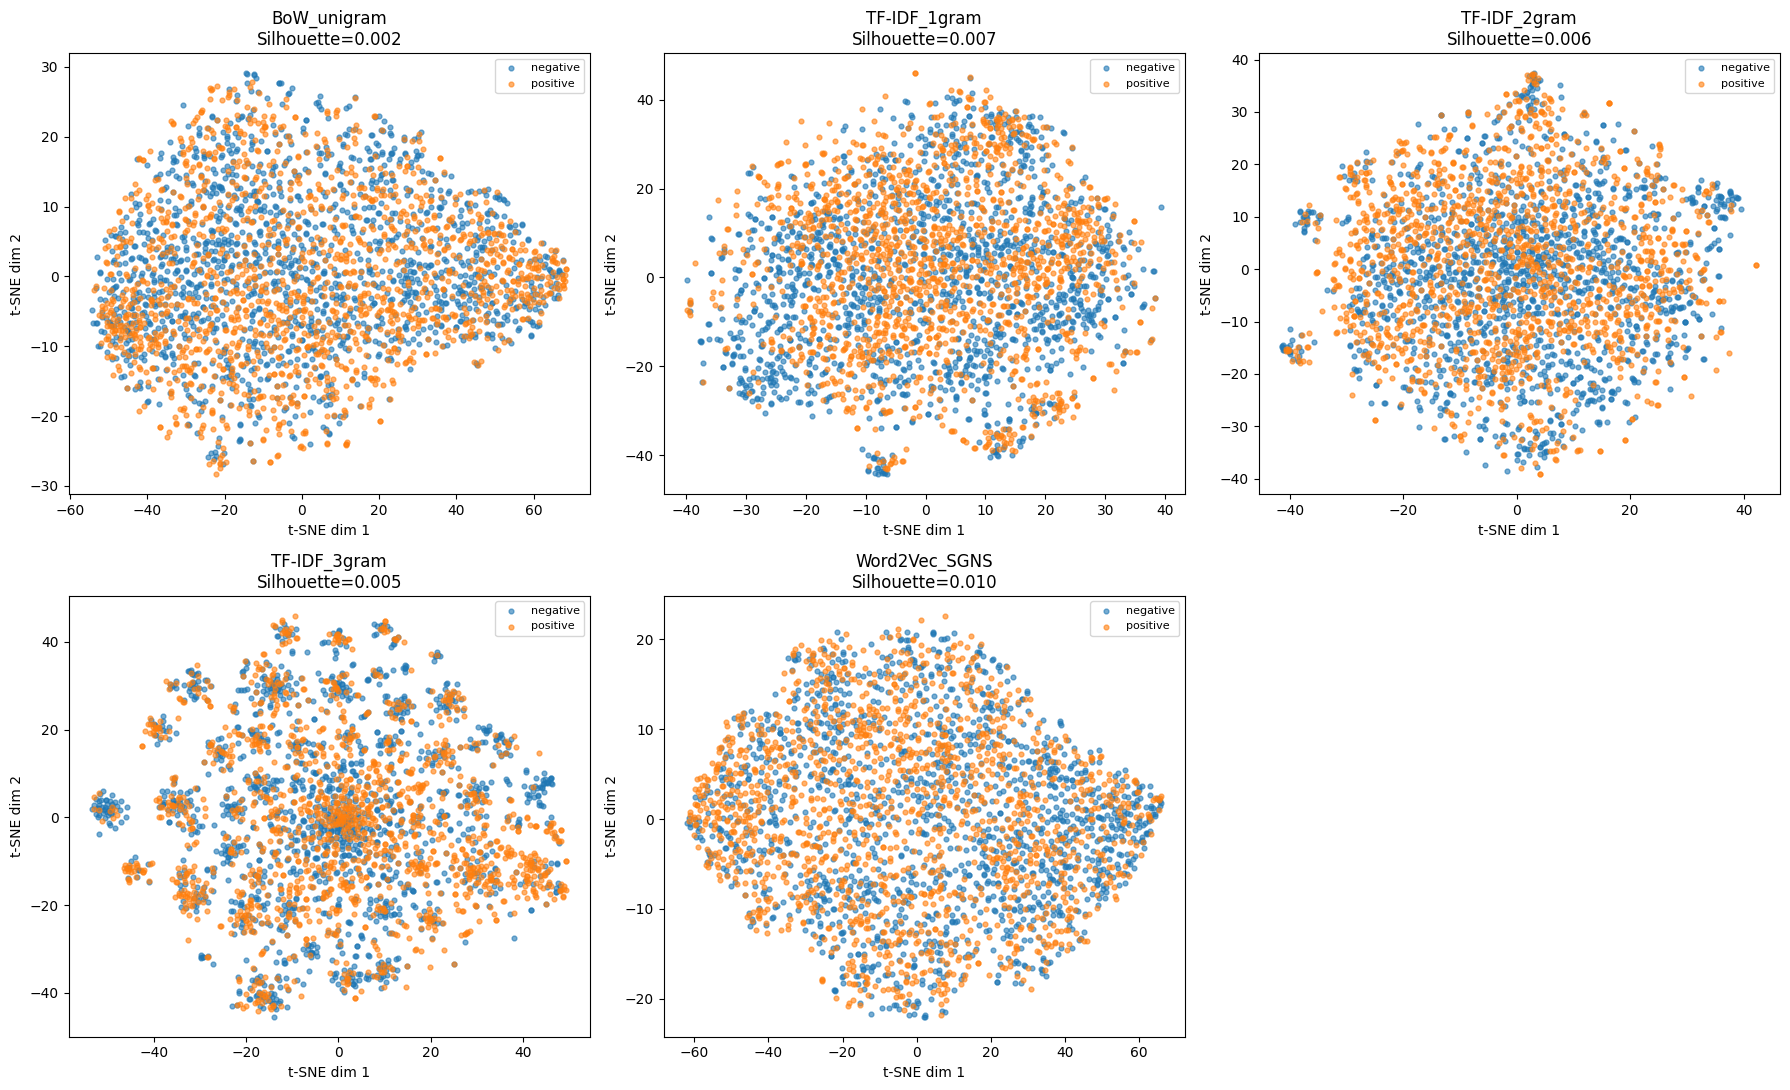

Bảng tổng hợp phân tích không gian đặc trưng:


,representation,n_docs,n_dims,sparsity_ratio,cos_same_mean,cos_diff_mean,cos_same_std,cos_diff_std,silhouette_tsne
0,BoW_unigram,3000,11804,0.989158,0.528704,0.523224,0.121948,0.126790,0.001740
1,TF-IDF_1gram,3000,11804,0.989158,0.133688,0.130626,0.050270,0.051856,0.007214
2,TF-IDF_2gram,3000,25000,0.995747,0.014935,0.014388,0.012115,0.012188,0.006182
3,TF-IDF_3gram,3000,17194,0.997958,0.003358,0.003482,0.009436,0.009710,0.005255
4,Word2Vec_SGNS,3000,50,0.000000,0.995583,0.995510,0.002764,0.002798,0.010003



Biến kết quả đã lưu:
- vector_space_results (dict)
- vector_space_comparison_df (DataFrame)
- tsne_coords_by_repr (tọa độ 2D cho từng biểu diễn)


In [14]:
# =======================
# 1) Chuẩn bị dữ liệu
# =======================
if 'prep_df' in globals() and 'text_step4_norm_space' in prep_df.columns:
    vec_texts_all = prep_df['text_step4_norm_space'].astype(str).tolist()
    vec_labels_all = prep_df['sentiment'].astype(str).tolist()
else:
    vec_texts_all = df['review'].astype(str).str.lower().tolist()
    vec_labels_all = df['sentiment'].astype(str).tolist()

VEC_SAMPLE_SIZE = 3000  # giảm để t-SNE chạy nhanh
VEC_RANDOM_STATE = 42
rng = np.random.default_rng(VEC_RANDOM_STATE)

if len(vec_texts_all) > VEC_SAMPLE_SIZE:
    sampled_idx = rng.choice(len(vec_texts_all), size=VEC_SAMPLE_SIZE, replace=False)
    vec_texts = [vec_texts_all[i] for i in sampled_idx]
    vec_labels = np.array([vec_labels_all[i] for i in sampled_idx])
else:
    vec_texts = vec_texts_all
    vec_labels = np.array(vec_labels_all)

# =======================
# 2) Hàm tiện ích
# =======================
def matrix_sparsity_ratio(X) -> float:
    if hasattr(X, 'nnz'):
        total = X.shape[0] * X.shape[1]
        density = X.nnz / total if total > 0 else 0.0
        return float(1.0 - density)
    total = X.size
    nnz = np.count_nonzero(X)
    density = nnz / total if total > 0 else 0.0
    return float(1.0 - density)

def _get_row_2d(X, idx: int):
    # cosine_similarity yêu cầu input 2D; đảm bảo mỗi mẫu có shape (1, n_features)
    if hasattr(X, 'ndim') and X.ndim == 2:
        return X[idx:idx + 1]
    row = np.asarray(X[idx]).reshape(1, -1)
    return row

def sample_cosine_same_diff(X, y, n_pairs=3000, seed=42):
    local_rng = np.random.default_rng(seed)
    y = np.array(y)
    classes = np.unique(y)

    same_scores = []
    diff_scores = []

    class_to_indices = {c: np.where(y == c)[0] for c in classes}
    valid_same_classes = [c for c in classes if len(class_to_indices[c]) >= 2]

    for _ in range(n_pairs):
        # same-class pair
        if valid_same_classes:
            c = valid_same_classes[local_rng.integers(0, len(valid_same_classes))]
            idx = class_to_indices[c]
            i, j = local_rng.choice(idx, size=2, replace=False)
            xi = _get_row_2d(X, int(i))
            xj = _get_row_2d(X, int(j))
            same_scores.append(float(cosine_similarity(xi, xj)[0, 0]))

        # different-class pair
        if len(classes) >= 2:
            c1, c2 = local_rng.choice(classes, size=2, replace=False)
            i = class_to_indices[c1][local_rng.integers(0, len(class_to_indices[c1]))]
            j = class_to_indices[c2][local_rng.integers(0, len(class_to_indices[c2]))]
            xi = _get_row_2d(X, int(i))
            xj = _get_row_2d(X, int(j))
            diff_scores.append(float(cosine_similarity(xi, xj)[0, 0]))

    return {
        'same_mean': float(np.mean(same_scores)) if same_scores else np.nan,
        'diff_mean': float(np.mean(diff_scores)) if diff_scores else np.nan,
        'same_std': float(np.std(same_scores)) if same_scores else np.nan,
        'diff_std': float(np.std(diff_scores)) if diff_scores else np.nan,
        'n_same_pairs': int(len(same_scores)),
        'n_diff_pairs': int(len(diff_scores)),
    }

def to_tsne_2d(X, random_state=42):
    # t-SNE làm việc tốt hơn trên không gian mật độ vừa phải; với sparse sẽ giảm chiều trước
    if hasattr(X, 'nnz'):
        svd_dim = int(min(50, X.shape[1] - 1)) if X.shape[1] > 1 else 1
        X_reduced = TruncatedSVD(n_components=svd_dim, random_state=random_state).fit_transform(X)
    else:
        X_reduced = X

    perplexity = int(min(30, max(5, len(X_reduced) // 20)))
    tsne = TSNE(
        n_components=2,
        random_state=random_state,
        init='pca',
        learning_rate='auto',
        perplexity=perplexity,
    )
    return tsne.fit_transform(X_reduced)

# =======================
# 3) BoW và TF-IDF n-gram
# =======================
representations = {}

bow_vectorizer = CountVectorizer(max_features=20000, min_df=3)
X_bow = bow_vectorizer.fit_transform(vec_texts)
representations['BoW_unigram'] = X_bow

for n in [1, 2, 3]:
    tfidf_vectorizer = TfidfVectorizer(ngram_range=(n, n), max_features=25000, min_df=3)
    X_tfidf = tfidf_vectorizer.fit_transform(vec_texts)
    representations[f'TF-IDF_{n}gram'] = X_tfidf

# =======================
# 4) Word2Vec (SGNS rút gọn bằng numpy)
# =======================
W2V_EMBED_DIM = 50
W2V_WINDOW = 2
W2V_MIN_COUNT = 5
W2V_MAX_VOCAB = 8000
W2V_NEGATIVE_K = 5
W2V_MAX_PAIRS = 50000
W2V_LR = 0.025
W2V_EPOCHS = 1

token_pattern = re.compile(r"[a-zA-Z']+")
tokenized_docs = [token_pattern.findall(t.lower()) for t in vec_texts]

# vocab
word_counter = Counter(w for doc in tokenized_docs for w in doc)
vocab_items = [it for it in word_counter.items() if it[1] >= W2V_MIN_COUNT]
vocab_items = sorted(vocab_items, key=lambda x: x[1], reverse=True)[:W2V_MAX_VOCAB]
w2v_vocab = [w for w, _ in vocab_items]
w2v_word2id = {w: i for i, w in enumerate(w2v_vocab)}
V = len(w2v_vocab)

# doc ids
doc_ids = [[w2v_word2id[w] for w in doc if w in w2v_word2id] for doc in tokenized_docs]

# tạo cặp center-context
pairs = []
for ids in doc_ids:
    L = len(ids)
    for i, c in enumerate(ids):
        left = max(0, i - W2V_WINDOW)
        right = min(L, i + W2V_WINDOW + 1)
        for j in range(left, right):
            if j != i:
                pairs.append((c, ids[j]))
                if len(pairs) >= W2V_MAX_PAIRS:
                    break
        if len(pairs) >= W2V_MAX_PAIRS:
            break
    if len(pairs) >= W2V_MAX_PAIRS:
        break

if V > 0 and pairs:
    W_in = rng.normal(0, 0.1, size=(V, W2V_EMBED_DIM)).astype(np.float32)
    W_out = np.zeros((V, W2V_EMBED_DIM), dtype=np.float32)

    # phân phối negative sampling
    freqs = np.array([word_counter[w] for w in w2v_vocab], dtype=np.float64)
    neg_probs = np.power(freqs, 0.75)
    neg_probs = neg_probs / neg_probs.sum()

    def sigmoid(x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -10, 10)))

    for _ in range(W2V_EPOCHS):
        perm = rng.permutation(len(pairs))
        for idx in perm:
            c, o = pairs[idx]
            v_c = W_in[c].copy()

            # positive
            score_pos = float(np.dot(W_out[o], v_c))
            g_pos = (1.0 - sigmoid(score_pos))

            # negative ids
            neg_ids = rng.choice(V, size=W2V_NEGATIVE_K, replace=True, p=neg_probs)

            grad_v = g_pos * W_out[o]
            W_out[o] += W2V_LR * g_pos * v_c

            for n_id in neg_ids:
                score_neg = float(np.dot(W_out[n_id], v_c))
                g_neg = (0.0 - sigmoid(score_neg))
                grad_v += g_neg * W_out[n_id]
                W_out[n_id] += W2V_LR * g_neg * v_c

            W_in[c] += W2V_LR * grad_v

    # vector văn bản = trung bình embedding token
    doc_vecs = np.zeros((len(doc_ids), W2V_EMBED_DIM), dtype=np.float32)
    for i, ids in enumerate(doc_ids):
        if ids:
            doc_vecs[i] = W_in[ids].mean(axis=0)
    representations['Word2Vec_SGNS'] = doc_vecs
else:
    # fallback nếu vocab quá nhỏ
    representations['Word2Vec_SGNS'] = np.zeros((len(vec_texts), W2V_EMBED_DIM), dtype=np.float32)

# =======================
# 5) Tính metric cho từng biểu diễn
# =======================
vector_space_results = {}
vector_space_rows = []
tsne_coords_by_repr = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for ax, (repr_name, X_repr) in zip(axes, representations.items()):
    # Đảm bảo input dạng 2D row vectors cho cosine_similarity
    if hasattr(X_repr, 'shape') and len(X_repr.shape) == 2:
        pass
    else:
        X_repr = np.asarray(X_repr)

    n_docs, n_dims = X_repr.shape
    sparsity = matrix_sparsity_ratio(X_repr)

    cos_stat = sample_cosine_same_diff(X_repr, vec_labels, n_pairs=2500, seed=VEC_RANDOM_STATE)

    X_tsne = to_tsne_2d(X_repr, random_state=VEC_RANDOM_STATE)
    tsne_coords_by_repr[repr_name] = X_tsne

    sil = float(silhouette_score(X_tsne, vec_labels)) if len(np.unique(vec_labels)) > 1 else np.nan

    vector_space_results[repr_name] = {
        'n_docs': int(n_docs),
        'n_dims': int(n_dims),
        'sparsity_ratio': float(sparsity),
        'cos_same_mean': cos_stat['same_mean'],
        'cos_diff_mean': cos_stat['diff_mean'],
        'cos_same_std': cos_stat['same_std'],
        'cos_diff_std': cos_stat['diff_std'],
        'silhouette_tsne': sil,
    }
    vector_space_rows.append({'representation': repr_name, **vector_space_results[repr_name]})

    for cls in np.unique(vec_labels):
        mask = vec_labels == cls
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=12, alpha=0.6, label=str(cls))
    ax.set_title(f'{repr_name}\nSilhouette={sil:.3f}')
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    ax.legend(fontsize=8)

# Ẩn trục thừa nếu số biểu diễn < số subplot
for i in range(len(representations), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

vector_space_comparison_df = pd.DataFrame(vector_space_rows).sort_values('representation').reset_index(drop=True)
print('Bảng tổng hợp phân tích không gian đặc trưng:')
display(vector_space_comparison_df)

print('\nBiến kết quả đã lưu:')
print('- vector_space_results (dict)')
print('- vector_space_comparison_df (DataFrame)')
print('- tsne_coords_by_repr (tọa độ 2D cho từng biểu diễn)')

**Phân tích kết quả**

Dùng `vector_space_comparison_df` để so sánh định lượng:

- `n_dims`, `sparsity_ratio`: BoW/TF-IDF thường có chiều cao và độ thưa lớn; Word2Vec thường dense hơn.
- `cos_same_mean` so với `cos_diff_mean`: chênh lệch càng lớn thì biểu diễn càng tách được quan hệ lớp tốt hơn theo độ đo cosine.
- `silhouette_tsne`: càng cao càng cho thấy cụm lớp tách tốt trên không gian 2D trực quan hóa.

Lưu ý: t-SNE nhạy với tham số và seed; nên xem silhouette như chỉ báo tham khảo kết hợp cùng cosine cùng lớp/khác lớp để kết luận chắc chắn hơn.

### f. Biểu diễn ngữ nghĩa bằng Sentence Transformer: 
Sử dụng mô hình pretrained (ví dụ: all-MiniLM-L6-v2 từ sentence-transformers). So sánh
chất lượng phân cụm (K-Means, silhouette score) và hiệu năng phân loại (Linear SVM)
giữa TF-IDF và Sentence Transformer embeddings. Giải thích sự khác biệt về mặt ngữ
nghĩa.

**Lý thuyết và công thức đánh giá**

So sánh hai không gian biểu diễn:

- TF-IDF: đặc trưng dựa trên tần suất bề mặt từ/cụm từ.
- Sentence Transformer: embedding ngữ nghĩa dense từ mô hình pretrained.

Chỉ số đánh giá:

- **K-Means + silhouette score**
  $$S = \frac{1}{N}\sum_i \frac{b(i)-a(i)}{\max(a(i), b(i))}$$
  $S$ càng cao thì cụm tách càng tốt.

- **Linear SVM (5-fold CV)**: dùng Accuracy và Macro-F1 để so sánh khả năng phân lớp.

Kỳ vọng: Sentence Transformer thường nắm bắt quan hệ ngữ nghĩa tốt hơn (đồng nghĩa/paraphrase), trong khi TF-IDF mạnh ở tín hiệu từ khóa trực tiếp.

In [15]:
# Cau hinh de can bang toc do / do chinh xac
SEM_SAMPLE_SIZE = 4000
SEM_SILHOUETTE_SAMPLE = 2000
SEM_RANDOM_STATE = 42

# Chon text dau vao
if 'prep_df' in globals() and 'text_step4_norm_space' in prep_df.columns:
    sem_texts_all = prep_df['text_step4_norm_space'].astype(str).tolist()
    sem_labels_all = prep_df['sentiment'].astype(str).tolist()
else:
    sem_texts_all = df['review'].astype(str).str.lower().tolist()
    sem_labels_all = df['sentiment'].astype(str).tolist()

sem_rng = np.random.default_rng(SEM_RANDOM_STATE)
if len(sem_texts_all) > SEM_SAMPLE_SIZE:
    sem_idx = sem_rng.choice(len(sem_texts_all), size=SEM_SAMPLE_SIZE, replace=False)
    sem_texts = [sem_texts_all[i] for i in sem_idx]
    sem_labels = np.array([sem_labels_all[i] for i in sem_idx])
else:
    sem_texts = sem_texts_all
    sem_labels = np.array(sem_labels_all)

# So cum tu dong theo so nhan
n_clusters = int(len(np.unique(sem_labels)))

# 1) TF-IDF embeddings
tfidf_sem_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=25000, min_df=3)
X_tfidf_sem = tfidf_sem_vectorizer.fit_transform(sem_texts)

# 2) Sentence Transformer embeddings
st_model_name = 'sentence-transformers/all-MiniLM-L6-v2'
st_model = SentenceTransformer(st_model_name)
X_st_sem = st_model.encode(sem_texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)

# Tinh silhouette tren mau de chay nhanh hon
if len(sem_texts) > SEM_SILHOUETTE_SAMPLE:
    sil_idx = sem_rng.choice(len(sem_texts), size=SEM_SILHOUETTE_SAMPLE, replace=False)
else:
    sil_idx = np.arange(len(sem_texts))

# KMeans + silhouette cho TF-IDF
kmeans_tfidf = KMeans(n_clusters=n_clusters, random_state=SEM_RANDOM_STATE, n_init=10)
tfidf_clusters = kmeans_tfidf.fit_predict(X_tfidf_sem[sil_idx])
tfidf_silhouette = float(silhouette_score(X_tfidf_sem[sil_idx], tfidf_clusters, metric='cosine'))

# KMeans + silhouette cho Sentence Transformer
kmeans_st = KMeans(n_clusters=n_clusters, random_state=SEM_RANDOM_STATE, n_init=10)
st_clusters = kmeans_st.fit_predict(X_st_sem[sil_idx])
st_silhouette = float(silhouette_score(X_st_sem[sil_idx], st_clusters, metric='cosine'))

# Linear SVM 5-fold CV
sem_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEM_RANDOM_STATE)

svm_tfidf = LinearSVC(random_state=SEM_RANDOM_STATE)
cv_tfidf = cross_validate(
    svm_tfidf, X_tfidf_sem, sem_labels, cv=sem_cv,
    scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'},
    n_jobs=1, return_train_score=False
 )

svm_st = LinearSVC(random_state=SEM_RANDOM_STATE)
cv_st = cross_validate(
    svm_st, X_st_sem, sem_labels, cv=sem_cv,
    scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'},
    n_jobs=1, return_train_score=False
 )

semantic_compare_results = {
    'tfidf': {
        'n_dims': int(X_tfidf_sem.shape[1]),
        'silhouette_kmeans': tfidf_silhouette,
        'svm_accuracy_mean': float(np.mean(cv_tfidf['test_accuracy'])),
        'svm_accuracy_std': float(np.std(cv_tfidf['test_accuracy'])),
        'svm_f1_macro_mean': float(np.mean(cv_tfidf['test_f1_macro'])),
        'svm_f1_macro_std': float(np.std(cv_tfidf['test_f1_macro'])),
    },
    'sentence_transformer': {
        'n_dims': int(X_st_sem.shape[1]),
        'silhouette_kmeans': st_silhouette,
        'svm_accuracy_mean': float(np.mean(cv_st['test_accuracy'])),
        'svm_accuracy_std': float(np.std(cv_st['test_accuracy'])),
        'svm_f1_macro_mean': float(np.mean(cv_st['test_f1_macro'])),
        'svm_f1_macro_std': float(np.std(cv_st['test_f1_macro'])),
    },
}

semantic_compare_df = pd.DataFrame([
    {'representation': 'TF-IDF', **semantic_compare_results['tfidf']},
    {'representation': 'SentenceTransformer', **semantic_compare_results['sentence_transformer']},
])

print('So sánh TF-IDF vs Sentence Transformer:')
display(semantic_compare_df)

print('\nBiến kết quả đã lưu:')
print('- semantic_compare_results (dict)')
print('- semantic_compare_df (DataFrame)')
print('- X_tfidf_sem, X_st_sem (embeddings)')
print('- tfidf_clusters, st_clusters (cụm KMeans trên mẫu silhouette)')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6424.56it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 63/63 [01:55<00:00,  1.83s/it]


So sánh TF-IDF vs Sentence Transformer:


,representation,n_dims,silhouette_kmeans,svm_accuracy_mean,svm_accuracy_std,svm_f1_macro_mean,svm_f1_macro_std
0,TF-IDF,25000,0.007224,0.87225,0.011303,0.872195,0.011312
1,SentenceTransformer,384,0.059260,0.80900,0.013588,0.808889,0.013553



Biến kết quả đã lưu:
- semantic_compare_results (dict)
- semantic_compare_df (DataFrame)
- X_tfidf_sem, X_st_sem (embeddings)
- tfidf_clusters, st_clusters (cụm KMeans trên mẫu silhouette)


**Phân tích khác biệt ngữ nghĩa**

Dựa trên `semantic_compare_df`:

- Nếu Sentence Transformer có silhouette cao hơn, embedding ngữ nghĩa đang gom các câu cùng “ý” tốt hơn kể cả khi khác từ vựng bề mặt.
- Nếu Linear SVM trên Sentence Transformer có Macro-F1 cao hơn, mô hình đang tận dụng tốt thông tin ngữ nghĩa toàn câu.
- Nếu TF-IDF vẫn cạnh tranh hoặc tốt hơn, dữ liệu sentiment đang phụ thuộc mạnh vào từ khóa rõ ràng (ví dụ `great`, `awful`) mà TF-IDF biểu diễn rất hiệu quả.

Kết luận thực nghiệm thường gặp: Sentence Transformer mạnh về **semantic similarity**, còn TF-IDF mạnh về **lexical specificity**; phương án tốt nhất phụ thuộc bản chất dữ liệu và mục tiêu bài toán.